# 1 — Robots, Simulation, MuJoCo and MJCF

SOC4180 · Robot and AI

Hong Jeong

<figure>
<a
href="https://colab.research.google.com/github/gnoejh/soc4180/blob/main/weeks/01-intro/lab.ipynb"><img
src="https://colab.research.google.com/assets/colab-badge.svg" /></a>
<figcaption>Open In Colab</figcaption>
</figure>

**Before you start, two things:**

1.  **Runtime → Change runtime type → T4 GPU.** Not for training —
    MuJoCo renders video through EGL on Colab, and that needs the GPU
    runtime.
2.  **File → Save a copy in Drive.** This notebook is opened from GitHub
    and is *not* saved. Without a copy, your work disappears when you
    close the tab.

## Where we are going

By week 5 you will make a humanoid walk using nothing but geometry and
physics you derived yourself.

By week 11 you will replace that hand-written controller with a policy
the robot learned on its own.

Today: why simulation, and how to drive one.

------------------------------------------------------------------------

## Why simulate a robot at all?

A real humanoid is expensive, fragile, and slow to reset.

- A fall costs money and repair time
- Experiments must be repeatable to be science
- Learning needs **millions** of trials — impossible on hardware
- Simulation runs faster than real time, and in parallel

This course is **simulation only**. Everything you build runs on your
laptop or in Colab.

------------------------------------------------------------------------

## The cost of simulating

Simulation is an approximation, and the places it is wrong are the
places robots fall over:

- Contact and friction are *hard* — the foot/ground interface is the
  whole game
- Actuators have limits, delays, and heat that models ignore
- Sensors are noiseless in sim and never noiseless in reality

The distance between simulation and reality is the **sim-to-real gap**.
We return to it in week 12.

------------------------------------------------------------------------

## MuJoCo

**Mu**lti-**Jo**int dynamics with **Co**ntact — a physics engine built
for exactly our problem: many joints, and contact with the ground.

- Free and open source
- Fast enough for reinforcement learning
- Strong contact model, which is why locomotion research uses it

``` bash
pip install mujoco
```

------------------------------------------------------------------------

## MJCF: a robot is a text file

MuJoCo reads **MJCF**, an XML format. One file describes an entire
robot, and each top-level section answers a different question about it.

``` xml
<mujoco model="my_robot">
  <compiler angle="radian" meshdir="assets"/>    <!-- how to read this file   -->
  <option timestep="0.002" gravity="0 0 -9.81"/> <!-- how the world behaves   -->
  <default>   ...  </default>                    <!-- values tags inherit     -->
  <asset>     ...  </asset>                      <!-- meshes, materials       -->
  <worldbody> ...  </worldbody>                  <!-- the robot: bodies       -->
  <actuator>  ...  </actuator>                   <!-- what you can command    -->
  <sensor>    ...  </sensor>                     <!-- what you can measure    -->
  <keyframe>  ...  </keyframe>                   <!-- named poses             -->
</mujoco>
```

A file with nothing but `<worldbody>` compiles happily. The other seven
sections are the difference between a shape and a robot.

------------------------------------------------------------------------

## Body, joint, geom

Three tags carry almost all the meaning.

``` xml
<body name="upper_leg" pos="0 0 1">                            <!-- frame + mass -->
  <joint name="hip" type="hinge" axis="0 1 0"/>                <!-- how it moves -->
  <geom type="capsule" size="0.05" fromto="0 0 0  0 0 -0.4"/>  <!-- its shape    -->

  <body name="lower_leg" pos="0 0 -0.4">                       <!-- a child link -->
    <joint name="knee" type="hinge" axis="0 1 0"/>
    <geom type="capsule" size="0.04" fromto="0 0 0  0 0 -0.4"/>
  </body>
</body>
```

- **`<body>`** — a coordinate frame carrying mass. `pos` is measured
  **from its parent**, not from the world — which is why moving the
  thigh moves the shin with it, and why you never recompute a child’s
  position by hand.
- **`<joint>`** — how this body may move *relative to its parent*. A
  body with no joint is welded to its parent and adds no freedom.
- **`<geom>`** — shape: what you see, and what collides.

Nesting `<body>` **is** the kinematic chain — rotate the hip and the
shin comes with it, because its frame is defined inside the thigh’s.
Week 2 makes this precise.

------------------------------------------------------------------------

## Our robot: Unitree G1

A full-size humanoid, and the robot we use all semester.

- Supplied by **MuJoCo Menagerie**, a curated model collection
- Released under BSD-3-Clause
- We pin one version, so the model never changes under you mid-semester

------------------------------------------------------------------------

## Setup

Run this cell first. On Colab it installs the course package; locally it
finds the environment `uv` already built and does nothing.

In [1]:
try:
    import soc4180
except ImportError:
    %pip install -q "soc4180 @ git+https://github.com/gnoejh/soc4180.git"
    import soc4180

Versions are pinned, so the robot you see today is the robot you see in
week 15.

------------------------------------------------------------------------

## Loading the robot

`soc4180` picks a working renderer for whichever machine you are on, so
the same code runs locally and on Colab.

In [2]:
import mujoco
import soc4180

soc4180.set_seed(4180)
print("GL backend:", soc4180.GL_BACKEND, "| Colab:", soc4180.is_colab())

model = soc4180.load_g1()   # fetches the pinned G1 on first use, then caches it
data = mujoco.MjData(model)

GL backend: default | Colab: False

------------------------------------------------------------------------

## What is in the model?

Three numbers describe the robot’s size as a dynamical system.

In [3]:
print(f"nq    = {model.nq:3d}   generalised coordinates (position)")
print(f"nv    = {model.nv:3d}   degrees of freedom (velocity)")
print(f"nu    = {model.nu:3d}   actuators (motors you can command)")
print(f"nbody = {model.nbody:3d}   rigid bodies")

nq    =  36   generalised coordinates (position)
nv    =  35   degrees of freedom (velocity)
nu    =  29   actuators (motors you can command)
nbody =  31   rigid bodies

**`nq` is larger than `nv`.** The floating base uses a 4-number
quaternion for orientation but has only 3 rotational DOF. A
free-floating robot is not a fixed robot arm, and that difference drives
everything about balance.

------------------------------------------------------------------------

## Which way is up?

Before any joint name makes sense, you need the frame those names live
in.

In [4]:
print("gravity     :", model.opt.gravity)
for side in ("left", "right"):
    b = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, f"{side}_hip_pitch_link")
    print(f"{side:5s} hip at:", model.body_pos[b])

gravity     : [ 0.    0.   -9.81]
left  hip at: [ 0.        0.064452 -0.1027  ]
right hip at: [ 0.       -0.064452 -0.1027  ]

- **`+z` is up** — gravity points along $-z$.
- **`+y` is the robot’s left** — the left hip sits at $y = +0.064$ m,
  the right at $y = -0.064$ m.
- **`+x` is forward.** You do not have to take that on faith: the frame
  is right-handed, and $x = y \times z$, so left-cross-up gives forward.

Lengths are **metres** and angles are **radians** —
`<compiler angle="radian"/>` said so. The `1.28` you saw in the `stand`
keyframe is an elbow bent 73°.

------------------------------------------------------------------------

## Roll, pitch, and yaw

Three words for turning about the three axes. Try them with your own
head:

| Name | Turns about | Your head | The robot |
|------------------|------------------|------------------|------------------|
| **roll** | `x` — forward | tilt an ear toward your shoulder | tipping sideways |
| **pitch** | `y` — left | nod “yes” | leaning forward or back |
| **yaw** | `z` — up | shake “no” | turning to face a new direction |

The G1’s joint names are not decoration — each one *is* its axis:

In [5]:
for n in ["left_hip_pitch_joint", "left_hip_roll_joint", "left_hip_yaw_joint",
          "left_knee_joint", "left_ankle_pitch_joint", "left_ankle_roll_joint"]:
    j = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n)
    print(f"{n:24s} axis {model.jnt_axis[j]}")

left_hip_pitch_joint     axis [0. 1. 0.]
left_hip_roll_joint      axis [1. 0. 0.]
left_hip_yaw_joint       axis [0. 0. 1.]
left_knee_joint          axis [0. 1. 0.]
left_ankle_pitch_joint   axis [0. 1. 0.]
left_ankle_roll_joint    axis [1. 0. 0.]

Check it across the whole robot — every named hinge agrees with its
axis:

In [6]:
axis_name = {(1, 0, 0): "roll", (0, 1, 0): "pitch", (0, 0, 1): "yaw"}
mismatch = []
for j in range(model.njnt):
    n = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, j)
    if not n or model.jnt_type[j] != mujoco.mjtJoint.mjJNT_HINGE:
        continue
    got = axis_name.get(tuple(int(round(v)) for v in model.jnt_axis[j]))
    for word in ("roll", "pitch", "yaw"):
        if word in n and got != word:
            mismatch.append((n, got))
print("joints whose name disagrees with their axis:", mismatch or "none")

joints whose name disagrees with their axis: none

------------------------------------------------------------------------

## Why a hip needs three and a knee needs one

The hip is **three separate joints stacked** — `hip_pitch`, `hip_roll`,
`hip_yaw` — because a leg must do three independent things:

- **pitch** — swing forward to take a step
- **roll** — spread sideways, and shift weight onto one foot
- **yaw** — turn the leg so the robot can change direction

The knee has only **pitch**: `left_knee_joint` has axis `[0 1 0]`, and
its range is `[-0.087, 2.880]` — it bends one way and essentially does
not straighten past zero. Yours is the same. That single-axis, one-sided
knee is why week 3’s inverse kinematics has a reachable set with a
*hole* in the middle.

Three notes you will need later:

- Two of these are easy to sense and one is not. An accelerometer feels
  gravity, so it can tell you **roll and pitch** — but gravity says
  nothing about which way you are *facing*, so **yaw is unobservable**
  from it. Week 6.
- Rotations do not commute: roll-then-pitch is not pitch-then-roll. This
  is why week 2 uses matrices and quaternions rather than three angles.
- The floating base stores its orientation as the quaternion
  `(w, x, y, z)` — **scalar first**, which is MuJoCo’s convention and
  not everyone’s.

------------------------------------------------------------------------

## Naming the joints

In [7]:
names = [
    mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, i)
    for i in range(model.njnt)
]
leg = [n for n in names if n and ("hip" in n or "knee" in n or "ankle" in n)]
print(f"{model.njnt} joints; {len(leg)} in the legs:")
for n in leg:
    print("   ", n)

30 joints; 12 in the legs:
    left_hip_pitch_joint
    left_hip_roll_joint
    left_hip_yaw_joint
    left_knee_joint
    left_ankle_pitch_joint
    left_ankle_roll_joint
    right_hip_pitch_joint
    right_hip_roll_joint
    right_hip_yaw_joint
    right_knee_joint
    right_ankle_pitch_joint
    right_ankle_roll_joint

These leg joints are the ones we will command to produce a step.

------------------------------------------------------------------------

## The file you actually loaded

`load_g1()` compiled a real file that is sitting on this machine. Here
it is, in full — the *scene*, which is not the robot.

In [8]:
from pathlib import Path

scene_xml = soc4180.robot_path("unitree_g1", "scene")
print(scene_xml, end="\n\n")
print(Path(scene_xml).read_text(encoding="utf-8"))

C:\Users\hjeong\AppData\Local\mujoco_menagerie\cache\models\unitree_g1-57c00d310bfd8ae7\scene.xml

<mujoco model="g1_29dof_rev_1_0 scene">
  <include file="g1.xml"/>

  <visual>
    <headlight diffuse="0.6 0.6 0.6" ambient="0.1 0.1 0.1" specular="0.9 0.9 0.9"/>
    <rgba haze="0.15 0.25 0.35 1"/>
    <global azimuth="140" elevation="-20"/>
  </visual>

  <asset>
    <texture type="skybox" builtin="gradient" rgb1="0.3 0.5 0.7" rgb2="0 0 0" width="512" height="3072"/>
    <texture type="2d" name="groundplane" builtin="checker" mark="edge" rgb1="0.2 0.3 0.4" rgb2="0.1 0.2 0.3"
      markrgb="0.8 0.8 0.8" width="300" height="300"/>
    <material name="groundplane" texture="groundplane" texuniform="true" texrepeat="5 5" reflectance="0.2"/>
  </asset>

  <worldbody>
    <geom name="floor" size="0 0 0.05" type="plane" material="groundplane"/>
  </worldbody>
</mujoco>


Twenty lines: a floor, a sky, a light — and `<include file="g1.xml"/>`,
which pulls in the robot. **The robot and its world are separate
files**, so the same G1 can be dropped onto a different floor without
editing the robot.

------------------------------------------------------------------------

## Reading the robot’s own file

`g1.xml` is 350 lines, so we print it one section at a time.

In [9]:
def mjcf(path, tag, limit=40):
    """Print one top-level block of an MJCF file: <tag> ... </tag>."""
    lines = Path(path).read_text(encoding="utf-8").splitlines()
    i = next(k for k, l in enumerate(lines) if l.lstrip().startswith(f"<{tag}"))
    if lines[i].rstrip().endswith("/>"):          # self-closing, e.g. <option .../>
        return print(lines[i].strip())
    pad = len(lines[i]) - len(lines[i].lstrip())  # close the tag at *this* depth
    j = next(k for k, l in enumerate(lines[i:], i)
             if l.lstrip().startswith(f"</{tag}") and len(l) - len(l.lstrip()) == pad)
    block = lines[i:j + 1]
    extra = len(block) - limit
    print("\n".join(block[:limit] + ([f"  ... {extra} more lines"] if extra > 0 else [])))

g1_xml = soc4180.robot_path("unitree_g1", "g1")
mjcf(g1_xml, "compiler")
mjcf(g1_xml, "option")

<compiler angle="radian" meshdir="assets"/>
<option integrator="implicitfast"/>

`angle="radian"` sets the units of every angle in the file. `meshdir`
says where the STL files live.

------------------------------------------------------------------------

## What the file does not say

That `<option>` line sets an integrator and nothing else. Yet the
simulation plainly has a timestep and a gravity vector:

In [10]:
print(f"timestep = {model.opt.timestep} s  ->  {1/model.opt.timestep:.0f} Hz")
print(f"gravity  = {model.opt.gravity}")

timestep = 0.002 s  ->  500 Hz
gravity  = [ 0.    0.   -9.81]

Those are **MuJoCo’s defaults**, not the model’s choices. An MJCF is a
*diff against a default robot*: every attribute you leave out still has
a value.

That cuts both ways. It keeps files short — and it means a number you
never wrote is shaping your results.

------------------------------------------------------------------------

## `<default>`: where `kp=500` comes from

Search the G1’s 29 actuator lines for a gain and you will not find one.

In [11]:
mjcf(g1_xml, "default")

  <default>
    <default class="g1">
      <site rgba="1 0 0 1" size="0.01" group="5"/>
      <joint armature="0.01" frictionloss="0.3"/>
      <position kp="500" dampratio="1" inheritrange="1"/>
      <default class="visual">
        <geom group="2" type="mesh" contype="0" conaffinity="0" density="0" material="metal"/>
      </default>
      <default class="collision">
        <geom group="3" type="mesh"/>
        <default class="foot">
          <geom type="sphere" size="0.005" priority="1" friction="0.6" condim="3"/>
        </default>
      </default>
    </default>
  </default>

`<default class="g1">` names a bundle of attributes. The pelvis carries
`childclass="g1"`, so every tag beneath it inherits them, and any tag
can opt into a class by name — `class="visual"`, `class="collision"`,
`class="foot"`.

**This is where the position gain of 500 that runs your whole semester
lives.** Classes nest: `foot` inherits from `collision`, which inherits
from `g1`.

------------------------------------------------------------------------

## One link, in full

In [12]:
mjcf(g1_xml, "body", limit=13)

    <body name="pelvis" pos="0 0 0.793" childclass="g1">
      <inertial pos="0 0 -0.07605" quat="1 0 -0.000399148 0" mass="3.813" diaginertia="0.010549 0.0093089 0.0079184"/>
      <freejoint name="floating_base_joint"/>
      <geom class="visual" material="black" mesh="pelvis"/>
      <geom class="visual" mesh="pelvis_contour_link"/>
      <geom class="collision" mesh="pelvis_contour_link"/>
      <site name="imu_in_pelvis" pos="0.04525 0 -0.08339" size="0.01"/>
      <body name="left_hip_pitch_link" pos="0 0.064452 -0.1027">
        <inertial pos="0.002741 0.047791 -0.02606" quat="0.954862 0.293964 0.0302556 0.030122" mass="1.35"
          diaginertia="0.00181517 0.00153422 0.00116212"/>
        <joint name="left_hip_pitch_joint" axis="0 1 0" range="-2.5307 2.8798" actuatorfrcrange="-88 88"/>
        <geom class="visual" material="black" mesh="left_hip_pitch_link"/>
        <geom class="collision" material="black" mesh="left_hip_pitch_link"/>
  ... 222 more lines

Everything a link can carry, in one place:

- `pos="0 0 0.793"` — the pelvis starts 79 cm above the floor
- `<inertial>` — mass and rotational inertia: the numbers the physics
  integrates
- `<freejoint>` — this body may translate and rotate freely: it is
  **not** bolted to the world
- `<geom class="visual">` twice, `class="collision"` once — one link,
  drawn one way and collided another
- `<site>` — a named point carrying no physics; sensors mount here
- then a nested `<body>`, where the left leg begins

------------------------------------------------------------------------

## Nesting is the kinematic chain

The compiled model remembers the tree that the XML indentation drew.

In [13]:
def tree(m, body=0, depth=0, maxdepth=2):
    name = mujoco.mj_id2name(m, mujoco.mjtObj.mjOBJ_BODY, body) or "world"
    print("    " * depth + name)
    if depth == maxdepth:
        return
    for b in range(m.nbody):
        if m.body_parentid[b] == body and b != body:
            tree(m, b, depth + 1, maxdepth)

tree(model, maxdepth=3)
print(f"\n{model.nbody} bodies in total")

world
    pelvis
        left_hip_pitch_link
            left_hip_roll_link
        right_hip_pitch_link
            right_hip_roll_link
        waist_yaw_link
            waist_roll_link

31 bodies in total

One root (`pelvis`) and three branches: two legs, and a waist carrying
torso, head and arms.

------------------------------------------------------------------------

## Every link is drawn twice

In [14]:
import numpy as np
from collections import Counter

groups = Counter(int(g) for g in model.geom_group)
non_colliding = sum((model.geom_contype[i] == 0) and (model.geom_conaffinity[i] == 0)
                    for i in range(model.ngeom))
print("geoms by group :", dict(sorted(groups.items())))
print("non-colliding  :", non_colliding, f"of {model.ngeom}")

foot = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "left_ankle_roll_link")
for g in range(model.ngeom):
    if model.geom_bodyid[g] == foot:
        print(f"  foot geom: group {model.geom_group[g]}  "
              f"type {mujoco.mjtGeom(model.geom_type[g]).name:14s} "
              f"collides={bool(model.geom_contype[g])}")

geoms by group : {0: 1, 2: 35, 3: 36}
non-colliding  : 35 of 72
  foot geom: group 2  type mjGEOM_MESH    collides=False
  foot geom: group 3  type mjGEOM_SPHERE  collides=True
  foot geom: group 3  type mjGEOM_SPHERE  collides=True
  foot geom: group 3  type mjGEOM_SPHERE  collides=True
  foot geom: group 3  type mjGEOM_SPHERE  collides=True

Group 2 is the pretty mesh, declared `contype="0" conaffinity="0"` —
**invisible to physics**. Group 3 is what actually touches the world.

The foot reaches the ground through **four spheres of 5 mm radius**, not
a mesh. Sphere contacts are cheap and stable; mesh-on-mesh contact is
neither. Choices like this one are what keep a 29-joint humanoid fast
enough to learn in.

------------------------------------------------------------------------

## Joints decide `nq` and `nv`

The joint type you write determines how many numbers the state needs.

In [15]:
def dof_count(joint_xml):
    xml = f"""<mujoco><worldbody><body pos="0 0 1">{joint_xml}
              <geom type="box" size=".1 .1 .1"/></body></worldbody></mujoco>"""
    m = mujoco.MjModel.from_xml_string(xml)
    return m.nq, m.nv

for label, tag in [("<freejoint/>",      "<freejoint/>"),
                   ('type="ball"',       '<joint type="ball"/>'),
                   ('type="slide"',      '<joint type="slide" axis="0 0 1"/>'),
                   ('type="hinge"',      '<joint type="hinge" axis="0 1 0"/>'),
                   ("no joint (welded)", "")]:
    nq, nv = dof_count(tag)
    print(f"{label:20s} nq={nq}  nv={nv}")

<freejoint/>         nq=7  nv=6
type="ball"          nq=4  nv=3
type="slide"         nq=1  nv=1
type="hinge"         nq=1  nv=1
no joint (welded)    nq=0  nv=0

`freejoint` and `ball` are the only rows where **`nq` exceeds `nv`**:
both store orientation as a 4-number quaternion for 3 real freedoms.

The G1 is one `freejoint` plus 29 hinges — `nq` = 7 + 29 = 36, `nv` =
6 + 29 = 35. The gap you met a few slides ago is now fully explained.

------------------------------------------------------------------------

## Actuators live outside the body tree

In [16]:
mjcf(g1_xml, "actuator", limit=6)

  <actuator>
    <position class="g1" name="left_hip_pitch_joint" joint="left_hip_pitch_joint"/>
    <position class="g1" name="left_hip_roll_joint" joint="left_hip_roll_joint"/>
    <position class="g1" name="left_hip_yaw_joint" joint="left_hip_yaw_joint"/>
    <position class="g1" name="left_knee_joint" joint="left_knee_joint"/>
    <position class="g1" name="left_ankle_pitch_joint" joint="left_ankle_pitch_joint"/>
  ... 29 more lines

A `<position>` actuator is a **servo**: you command an angle and an
internal loop with gain `kp` produces the torque. Note what is *not*
written — the limits.

In [17]:
a = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "left_knee_joint")
j = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "left_knee_joint")
print("joint range   :", np.round(model.jnt_range[j], 4))
print("ctrl range    :", np.round(model.actuator_ctrlrange[a], 4))
print("position gain :", model.actuator_gainprm[a][0])

joint range   : [-0.0873  2.8798]
ctrl range    : [-0.0873  2.8798]
position gain : 500.0

`inheritrange="1"` in the class copied the joint’s range onto the
actuator, so a command outside the joint’s travel cannot even be
expressed. The gain came from the class too.

**29 actuators for 35 degrees of freedom.** The missing six are the
floating base: nothing pushes the robot around except the floor.

------------------------------------------------------------------------

## Sensors attach to sites

In [18]:
mjcf(g1_xml, "sensor")

  <sensor>
    <gyro site="imu_in_torso" name="imu-torso-angular-velocity" cutoff="34.9" noise="0.0005"/>
    <accelerometer site="imu_in_torso" name="imu-torso-linear-acceleration" cutoff="157" noise="0.01"/>
    <gyro site="imu_in_pelvis" name="imu-pelvis-angular-velocity" cutoff="34.9" noise="0.0005"/>
    <accelerometer site="imu_in_pelvis" name="imu-pelvis-linear-acceleration" cutoff="157" noise="0.01"/>
  </sensor>

Every sensor names a `<site>` — the frame it measures in. Move that site
in the XML and the readings change, exactly as remounting the real IMU
would.

Note what is **absent**: no camera, no foot contact switch, no
joint-torque sensor. A robot cannot sense what its file does not
declare. The `noise` and `cutoff` attributes are a week-6 topic.

------------------------------------------------------------------------

## Keyframes: named poses

In [19]:
mjcf(g1_xml, "keyframe")

key = model.key_qpos[0]
print("\nposition   :", key[:3])
print("quaternion :", key[3:7], " (w, x, y, z — scalar first)")
names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, i) for i in range(model.njnt)]
bent = {n: float(key[model.jnt_qposadr[i]])
        for i, n in enumerate(names)
        if n != "floating_base_joint" and key[model.jnt_qposadr[i]]}
print("non-zero joints:", bent)

  <keyframe>
    <key name="stand" qpos="0 0 0.79 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0.2 0.2 0 1.28 0 0 0 0.2 -0.2 0 1.28 0 0 0"
      ctrl="0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0.2 0.2 0 1.28 0 0 0 0.2 -0.2 0 1.28 0 0 0"/>
  </keyframe>

position   : [0.   0.   0.79]
quaternion : [1. 0. 0. 0.]  (w, x, y, z — scalar first)
non-zero joints: {'left_shoulder_pitch_joint': 0.2, 'left_shoulder_roll_joint': 0.2, 'left_elbow_joint': 1.28, 'right_shoulder_pitch_joint': 0.2, 'right_shoulder_roll_joint': -0.2, 'right_elbow_joint': 1.28}

Those 36 numbers are exactly `qpos`: 3 for position, 4 for the
quaternion, 29 for the joints. `<key>` sets `ctrl` too, so the servos
are told to hold the pose the robot starts in.

Only the arms are bent. **Every leg joint is exactly zero** — perfectly
straight legs. It looks tidy, and it is a trap: week 4 shows why inverse
kinematics cannot escape it.

------------------------------------------------------------------------

## XML in, arrays out

The compiler flattens the tree into arrays. Learning this mapping is
most of what “knowing MuJoCo” means:

| In the file | In `model` |
|------------------------------------|------------------------------------|
| `<body pos="...">` | `body_pos`, `body_parentid`, `body_mass` |
| `<joint type=... range=...>` | `jnt_type`, `jnt_range`, `jnt_qposadr` |
| `<geom class="collision">` | `geom_type`, `geom_group`, `geom_contype` |
| `<position kp="500">` | `actuator_gainprm`, `actuator_ctrlrange` |
| `<site>` | `site_pos`, and `data.site_xpos` once kinematics runs |
| `<key qpos="...">` | `key_qpos`, `key_ctrl` |
| `<option>` and defaults | `model.opt` |

Names are optional in MJCF — the G1’s foot spheres have none — but ids
always exist. `mj_name2id` and `mj_id2name` cross between the two
worlds.

------------------------------------------------------------------------

## Now write one yourself

A robot, from nothing, in twenty lines.

In [20]:
LEG = """
<mujoco model="two_link_leg">
  <option timestep="0.002"/>
  <worldbody>
    <light pos="0 0 3" dir="0 0 -1" directional="true"/>
    <geom name="floor" type="plane" size="5 5 0.05" rgba="0.3 0.4 0.5 1"/>

    <body name="upper_leg" pos="0 0 1">
      <joint name="hip" type="hinge" axis="0 1 0"/>
      <geom type="capsule" size="0.05" fromto="0 0 0  0 0 -0.4" rgba="0.7 0.7 0.7 1"/>

      <body name="lower_leg" pos="0 0 -0.4">
        <joint name="knee" type="hinge" axis="0 1 0"/>
        <geom type="capsule" size="0.04" fromto="0 0 0  0 0 -0.4" rgba="0.2 0.2 0.2 1"/>
      </body>
    </body>
  </worldbody>

  <actuator>
    <position name="hip"  joint="hip"  kp="200" dampratio="1"/>
    <position name="knee" joint="knee" kp="200" dampratio="1"/>
  </actuator>
</mujoco>
"""

leg = mujoco.MjModel.from_xml_string(LEG)
print(f"nq={leg.nq}  nv={leg.nv}  nu={leg.nu}  nbody={leg.nbody}  ngeom={leg.ngeom}")

nq=2  nv=2  nu=2  nbody=3  ngeom=3

Two hinges, so `nq = nv = 2`. `nbody` is 3 because the world itself
counts as a body. There is no `<freejoint>`, so the hip is bolted to the
sky: this leg cannot fall over, only swing.

------------------------------------------------------------------------

## Your robot, servos on and off

Start it bent, and ask the servos to **hold that bent pose** — a pose
gravity would never choose.

In [21]:
TARGET = np.array([1.2, -0.8])          # hip forward, knee bent

data_leg = mujoco.MjData(leg)
data_leg.qpos[:] = TARGET
data_leg.ctrl[:] = TARGET               # servos: stay exactly where you are
servo = soc4180.render_rollout(leg, data_leg, duration=3.0, fps=30, width=480, height=360)
print("servos on :", np.round(data_leg.qpos, 3), " droop:", np.round(data_leg.qpos - TARGET, 3))

data_leg = mujoco.MjData(leg)
data_leg.qpos[:] = TARGET
with soc4180.actuation_disabled(leg):
    passive = soc4180.render_rollout(leg, data_leg, duration=3.0, fps=30,
                                     width=480, height=360)
print("no actuation:", np.round(data_leg.qpos, 3))

soc4180.show_video(servo, fps=30)
soc4180.show_video(passive, fps=30)

servos on : [ 1.12  -0.807]  droop: [-0.08  -0.007]
no actuation: [0.433 1.757]

Same file, same start, same gravity. The first is a machine holding a
pose; the second is a double pendulum. **The difference is entirely
`<actuator>`** — the week-0 lesson, in a model you wrote yourself.

It does not hold *perfectly*: the hip sags a few hundredths of a radian.
A proportional servo only makes torque when it is already wrong, so
gravity always wins a little. That residue is where week 5 begins.

------------------------------------------------------------------------

## The droop, against the gain

A proportional servo produces torque only through its error, so holding
a load means holding an error: $\tau = k_p(\text{ctrl} - q)$ balances
gravity’s torque $\tau_g$ at a droop of
$q - \text{ctrl} = -\tau_g / k_p$.

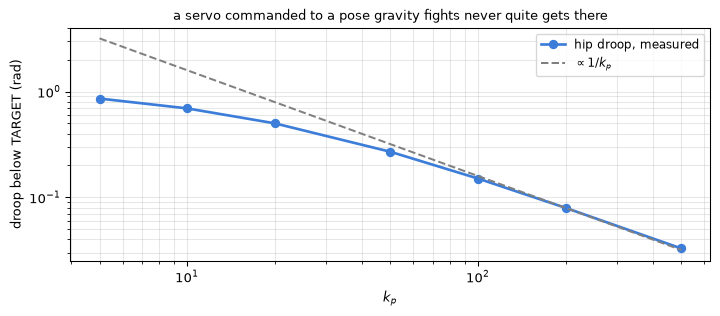

droop at kp=200: -0.0795 rad; at kp=5: -0.858 rad

In [22]:
import matplotlib.pyplot as plt

def droop(kp, seconds=3.0):
    m = mujoco.MjModel.from_xml_string(LEG.replace('kp="200"', f'kp="{kp}"'))
    d = mujoco.MjData(m); d.qpos[:] = TARGET; d.ctrl[:] = TARGET
    while d.time < seconds:
        mujoco.mj_step(m, d)
    return d.qpos - TARGET

gains = np.array([5, 10, 20, 50, 100, 200, 500])
hip = np.array([droop(k)[0] for k in gains])
fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.loglog(gains, -hip, "o-", lw=2, color="#3b7dd8", label="hip droop, measured")
ax.loglog(gains, -hip[-2] * 200 / gains, "--", color="0.5", label=r"$\propto 1/k_p$")
ax.set_xlabel("$k_p$"); ax.set_ylabel("droop below TARGET (rad)"); ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both")
ax.set_title("a servo commanded to a pose gravity fights never quite gets there", fontsize=10)
fig.tight_layout(); plt.show()
print("droop at kp=200:", f"{hip[-2]:+.4f} rad;", "at kp=5:", f"{hip[0]:+.3f} rad")

Ten times the gain, a tenth of the error — and never zero. Removing the
error entirely needs a term that remembers (an integrator) or one that
knows about gravity in advance (feedforward). Both are week 5.

------------------------------------------------------------------------

## `model` is the robot; `data` is the moment

You have been using both since the third cell. They are not the same
kind of thing, and confusing them is the most common MuJoCo mistake.

In [23]:
print("model  — compiled from the XML, and constant while you simulate")
print(f"   nq={model.nq}  nv={model.nv}  nu={model.nu}   body_pos, jnt_range, actuator_gainprm ...")

d = mujoco.MjData(model)
print("\ndata   — everything that changes")
print(f"   qpos {d.qpos.shape}   joint positions")
print(f"   qvel {d.qvel.shape}   joint velocities")
print(f"   ctrl {d.ctrl.shape}   what you command")
print(f"   xpos {d.xpos.shape}  where every body ended up, in world coordinates")
print(f"   time {d.time}")

model  — compiled from the XML, and constant while you simulate
   nq=36  nv=35  nu=29   body_pos, jnt_range, actuator_gainprm ...

data   — everything that changes
   qpos (36,)   joint positions
   qvel (35,)   joint velocities
   ctrl (29,)   what you command
   xpos (31, 3)  where every body ended up, in world coordinates
   time 0.0

`model` is the blueprint; `data` is one robot, at one instant, in one
universe.

**One `model` can serve many `data`.** That is not a curiosity — it is
how week 10 runs thousands of robots at once on a GPU: one description,
thousands of moments.

------------------------------------------------------------------------

## One step of physics

In [24]:
d = soc4180.keyframe_data(model, "stand")
print(f"before  t={d.time:.3f}s  pelvis z={d.qpos[2]:.6f}  max |qvel|={np.abs(d.qvel).max():.4f}")

mujoco.mj_step(model, d)

print(f"after   t={d.time:.3f}s  pelvis z={d.qpos[2]:.6f}  max |qvel|={np.abs(d.qvel).max():.4f}")
print(f"\none step advanced time by exactly opt.timestep = {model.opt.timestep} s")

before  t=0.000s  pelvis z=0.790000  max |qvel|=0.0000
after   t=0.002s  pelvis z=0.790018  max |qvel|=0.0159

one step advanced time by exactly opt.timestep = 0.002 s

That is the whole simulation. Everything else in this course is a
decision about what to write into `data.ctrl` before each step:

``` python
while not done:
    data.ctrl[:] = my_controller(data)   # weeks 2-6: maths.  weeks 7-10: a policy.
    mujoco.mj_step(model, data)
```

`mj_step` advances time. Its cousin **`mj_forward`** computes positions
from `qpos` *without* advancing time — that is what draws a pose without
letting the robot fall over, and why `render_poses` exists for the
kinematics weeks.

------------------------------------------------------------------------

## Faster than real time

The whole argument for simulation is on this slide.

In [25]:
import time

d = soc4180.keyframe_data(model, "stand")
N = 5000
t0 = time.perf_counter()
for _ in range(N):
    mujoco.mj_step(model, d)
elapsed = time.perf_counter() - t0

sim_seconds = N * model.opt.timestep
print(f"{N} steps in {elapsed:.2f} s of your life")
print(f"  = {N/elapsed:,.0f} physics steps per second")
print(f"  = {sim_seconds:.1f} s of robot time in {elapsed:.2f} s  ->  {sim_seconds/elapsed:.0f}x real time")

5000 steps in 0.31 s of your life
  = 16,348 physics steps per second
  = 10.0 s of robot time in 0.31 s  ->  33x real time

A 29-joint humanoid, tens of times faster than reality, on one core of
whatever machine you happen to be on. A real G1 falls over in real time,
once, and then needs repairing.

Hold on to your number. In week 10 you will want **150 million** steps,
and this is the figure that decides whether that takes an afternoon or a
month.

------------------------------------------------------------------------

## Watching it fall

Back to the G1, and do to it exactly what you just did to your own leg.
We start from the `<keyframe>` pose you read a few slides ago and
**switch its motors off**, then let physics run. (Week 0: `ctrl = 0`
would *not* do this — the position servos would hold a pose. To get no
controller at all, actuation must be disabled.)

In [26]:
with soc4180.actuation_disabled(model):          # every servo dead
    data = soc4180.keyframe_data(model, "stand")
    frames = soc4180.render_rollout(
        model, data, duration=3.0, fps=30, width=640, height=480
    )
soc4180.show_video(frames, fps=30)

------------------------------------------------------------------------

## What you just saw

The robot collapsed. That is the correct result.

A humanoid is an **unstable** system: left alone it falls, exactly like
a broomstick balanced on your palm. Every remaining week of this course
exists to answer one question —

> what should the motors do, at each instant, so that it does not fall?

Weeks 2–6 answer it with mathematics. Weeks 8–14 answer it with
learning.

------------------------------------------------------------------------

## The numbers behind the video

Contacts are not declared anywhere in the MJCF. MuJoCo *finds* them,
every step, and you can read them.

In [27]:
d = soc4180.keyframe_data(model, "stand")     # servos on: the robot just stands
for _ in range(1000):
    mujoco.mj_step(model, d)

force = np.zeros(6)
total = 0.0
for i in range(d.ncon):
    mujoco.mj_contactForce(model, d, i, force)
    total += force[0]                          # normal component

print(f"contacts        : {d.ncon}")
print(f"sum of normals  : {total:.1f} N")
print(f"weight (m*g)    : {model.body_mass.sum() * 9.81:.1f} N")

contacts        : 8
sum of normals  : 327.1 N
weight (m*g)    : 327.1 N

**Eight contacts** — the four spheres under each foot, exactly the geoms
you found in the XML. And the ground pushes up with precisely the
robot’s weight, because a standing robot is not accelerating. That is
Newton’s third law falling out of the simulator, and it is the first
thing to check when a robot misbehaves.

Week 4 lives entirely inside this number: to walk, you must move where
those contact forces act.

------------------------------------------------------------------------

## Watching the floor push back

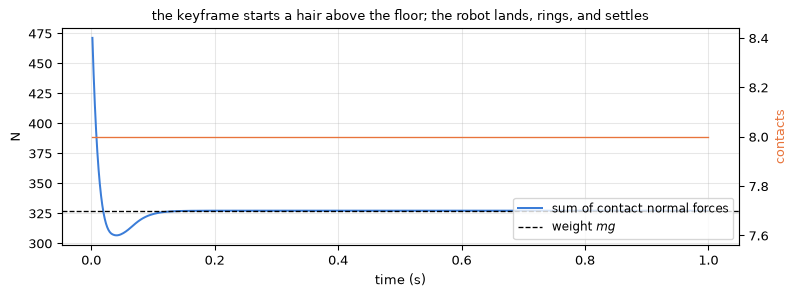

In [28]:
d = soc4180.keyframe_data(model, "stand")
t, total, ncon = [], [], []
force = np.zeros(6)
while d.time < 1.0:
    mujoco.mj_step(model, d)
    s = 0.0
    for i in range(d.ncon):
        mujoco.mj_contactForce(model, d, i, force); s += force[0]
    t.append(d.time); total.append(s); ncon.append(d.ncon)

fig, ax = plt.subplots(figsize=(8.4, 3.2))
ax.plot(t, total, lw=1.5, color="#3b7dd8", label="sum of contact normal forces")
ax.axhline(model.body_mass.sum() * 9.81, color="k", ls="--", lw=1, label="weight $mg$")
ax.set_xlabel("time (s)"); ax.set_ylabel("N"); ax.legend(fontsize=9, loc="lower right"); ax.grid(alpha=0.3)
ax2 = ax.twinx(); ax2.plot(t, ncon, color="#e8743b", lw=1, drawstyle="steps-post"); ax2.set_ylabel("contacts", color="#e8743b")
ax.set_title("the keyframe starts a hair above the floor; the robot lands, rings, and settles", fontsize=10)
fig.tight_layout(); plt.show()

$$\sum_i F_{n,i} = m g \quad\text{once nothing is accelerating}$$

The first few milliseconds are a landing: the keyframe places the robot
a fraction of a millimetre above the floor, the spheres touch down one
by one, and the force overshoots before the servos settle. After that
the sum is the weight, to the decimal.

------------------------------------------------------------------------

## Run it twice

In [29]:
knee = model.jnt_qposadr[mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "left_knee_joint")]

def fall(nudge=0.0, steps=1500):
    d = soc4180.keyframe_data(model, "stand")
    d.qpos[knee] += nudge
    with soc4180.actuation_disabled(model):
        for _ in range(steps):
            mujoco.mj_step(model, d)
    return d.qpos.copy()

base = fall()
print(f"same run, twice        : max difference {np.abs(base - fall()).max():.1e}")
for nudge in (1e-12, 1e-9, 1e-6):
    diff = np.abs(base - fall(nudge)).max()
    print(f"knee nudged {nudge:.0e} rad : max difference {diff:.1e}   ({diff/nudge:,.0f}x bigger)")

same run, twice        : max difference 0.0e+00
knee nudged 1e-12 rad : max difference 9.9e-08   (98,530x bigger)
knee nudged 1e-09 rad : max difference 7.2e-04   (716,465x bigger)
knee nudged 1e-06 rad : max difference 1.2e+00   (1,174,268x bigger)

Two facts, and they only *look* contradictory:

- **On one machine, the simulator is exactly deterministic** — the
  difference is a hard zero, not “small”. Same input, same arithmetic,
  same answer.
- **A falling robot amplifies everything.** A knee nudge of $10^{-12}$
  rad moves the foot about $3 \times 10^{-13}$ m — a fraction of an
  atom’s width — and it grows five orders of magnitude in three seconds.
  At $10^{-6}$ rad the robot lands somewhere else entirely.

So the same code on a different machine gives a *different* fall — not
through randomness, but because the arithmetic is reordered. Ours
settles at 0.134 m here and 0.142 m on a Colab T4.

**Therefore, all semester: never assert an exact number from a fall, and
never grade one.** Assert direction and size — “dropped more than 0.5
m”, “stayed above 0.7 m”. A stable robot reproduces exactly; a falling
one never will.

------------------------------------------------------------------------

## The amplification, over time

Chaos has a signature: the gap between two nearby runs grows
**exponentially**, $\delta(t) \approx \delta_0\, e^{\lambda t}$, and
$\lambda$ is a property of the system, not of the nudge.

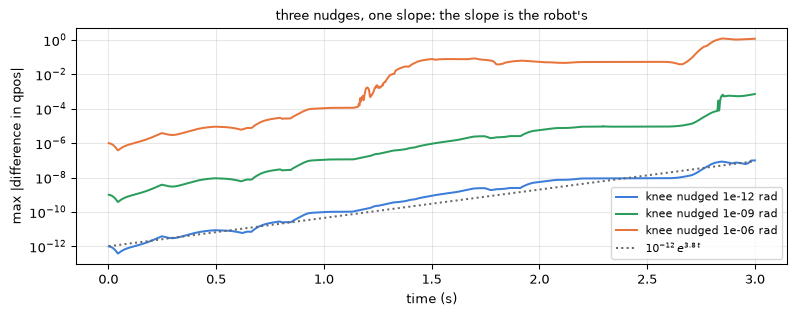

In [30]:
def fall_trace(nudge, steps=1500):
    d = soc4180.keyframe_data(model, "stand"); d.qpos[knee] += nudge; out = []
    with soc4180.actuation_disabled(model):
        for _ in range(steps):
            mujoco.mj_step(model, d); out.append(d.qpos.copy())
    return np.array(out)

ref = fall_trace(0.0)
tt = np.arange(1, 1501) * model.opt.timestep
fig, ax = plt.subplots(figsize=(8.4, 3.4))
for nudge, col in ((1e-12, "#3b7dd8"), (1e-9, "#2a9d5c"), (1e-6, "#e8743b")):
    gap = np.abs(fall_trace(nudge) - ref).max(axis=1)
    ax.semilogy(tt, np.maximum(gap, 1e-17), lw=1.5, color=col, label=f"knee nudged {nudge:.0e} rad")
ax.semilogy(tt, 1e-12 * np.exp(3.8 * tt), ls=":", color="0.4", label=r"$10^{-12}\,e^{3.8\,t}$")
ax.set_xlabel("time (s)"); ax.set_ylabel("max |difference in qpos|"); ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3, which="both"); ax.set_title("three nudges, one slope: the slope is the robot's", fontsize=10)
fig.tight_layout(); plt.show()

Parallel lines on a log axis: the *rate* of separation is the same for
all three, and it is about $e^{3.8}$ — forty-fold — per second. That
number belongs to the falling robot, and it is why the same code gives a
different heap on a different machine.

------------------------------------------------------------------------

## Lab class: on your laptop

``` bash
uv run weeks/01-intro/lab_mjcf.py
```

The two-link leg as text at the top of the file, annotated tag by tag;
the script compiles it, prints what the compiler made, and holds
`TARGET`. `A` kills the servos, `0` commands zero, `T` restores the
target, `G` is the Moon, `ENTER` prints the droop and the `BADQACC`
count. Every step: edit the XML, run.

| Step | Change | Right looks like |
|------------------------|------------------------|------------------------|
| 1 | none; `A`, `A`, `ENTER` | a pendulum, then a held pose; hip droop −0.080 rad, explained |
| 2 | `<freejoint/>` on `upper_leg`, then a parent body | the refusal read aloud; `nq = 9`, `nv = 8` predicted first |
| 3 | `kp` 200 → 5 | droop −0.080, −0.151, −0.269, −0.501, −0.858: never zero |
| 4 | `timestep="0.02"` | servos off: merely different; servos on: `BADQACC`, `qpos` reset to zero |
| 5 | a foot body with a hinge | `nq` up by one, and it moves with the knee |
| 6 | `rgba` into a `<default>` class | the picture unchanged |

------------------------------------------------------------------------

## Lab class: `mjcf_run.py`

``` bash
uv run weeks/01-intro/mjcf_run.py --kp 20 --seconds 3
uv run weeks/01-intro/mjcf_run.py --timestep 0.02 --no-viewer
uv run weeks/01-intro/mjcf_run.py --xml my_robot.xml --target 0.5 0.5 0
```

The same leg, or any MJCF file, with `kp`, the timestep, the servos and
gravity as flags: compile → print → simulate → replay, in six numbered
steps.

| Step | Does | Calls |
|------------------------|------------------------|------------------------|
| 1 | compile; apply the flags (`kv` rescaled with `kp`) | `MjModel.from_xml_string`, `opt.timestep`, `actuator_gainprm` |
| 2 | print what the compiler made | `jnt_qposadr`, `jnt_dofadr`, `mj_id2name` |
| 3 | put the leg at the target, command it | `jnt_qposadr[actuator_trnid]`, `ctrl` |
| 4 | the loop: a row of angles, droop, `BADQACC` per half second | `mj_step`, `data.warning` |
| 6 | replay the recorded motion | `launch_viewer(passive=True)`, `mj_forward`, `sync` |

------------------------------------------------------------------------

## Exercises: the G1

1.  Re-run the fall with `duration=6.0`. Where does the robot come to
    rest?
2.  Print the joint **limits** (`model.jnt_range`). Which joints are
    unlimited, and why?
3.  Set one hip joint to a non-zero angle in `data.qpos` before
    rendering. Does the robot fall differently?
4.  `model.opt.gravity` holds the gravity vector. Set it to the Moon’s
    $-1.62\ \text{m/s}^2$ and re-render. Does the robot fall more slowly
    than you expected?
5.  `mjcf(g1_xml, "asset", limit=8)` lists the meshes. How many STL
    files does one humanoid need, and what does that say about where
    model-building effort actually goes?
6.  The `foot` class sets `friction="0.6"`. Find it in
    `model.geom_friction`, then explain why only the *foot* spheres
    needed it and the elbow did not.
7.  Set `left_hip_roll_joint` to 0.4 rad in `data.qpos`, run
    `mj_forward`, and render the pose. Which way did the leg go? Now do
    the same with `left_hip_yaw_joint`. Name each motion before you
    look.
8.  Make two `MjData` from the one `model`. Step one 500 times and leave
    the other alone. Confirm `model` is unchanged and the two `data`
    disagree — this is the week-10 trick in miniature.
9.  From your measured steps-per-second, work out how long week 10’s
    **150 million** steps would take on this machine, in hours. Then
    read the week-10 title again.
10. Watch `data.ncon` during the fall — print it every 100 steps. When
    does it exceed 8, and which body has just hit the floor?
11. Re-run *Run it twice* with a **6 s** fall instead of 3 s. Does the
    amplification grow? Should it?

------------------------------------------------------------------------

## Exercises: your own MJCF

1.  Add `<freejoint/>` to `upper_leg` and re-compile. It refuses: *“more
    than 6 dofs in body ‘upper_leg’”*. A free joint **is** a body’s
    entire freedom, so it cannot share a body with a hinge. Fix it by
    wrapping the leg in a parent body that carries the `<freejoint/>`,
    predict `nq` and `nv`, then re-render. What can the leg do now that
    it could not?
2.  Sweep the servo gain — `kp` = 200, 100, 50, 20, 5 — and record the
    hip’s droop from `TARGET`. Plot droop against `kp`. Does the error
    ever reach zero, and what would you have to add to the controller to
    make it?
3.  Change `<option timestep="0.002"/>` to `0.02`. Re-run the
    **passive** swing: nothing crashes, nothing warns, and the final
    angles are simply different. Now re-run it **with the servos on**
    and inspect `data_leg.warning`. One of those two results is a silent
    approximation and the other is a silent failure — which is which,
    and which would have fooled you?
4.  Add a third body, a foot, below `lower_leg`, with its own hinge.
    Confirm `nq` rose by one and that the foot moves when the knee does.
5.  Replace the repeated `rgba` on the two capsules with a `<default>`
    class. Confirm the render is unchanged — this is the same mechanism
    that hides `kp=500` in the G1.

------------------------------------------------------------------------

## Next week

**Rigid-body transforms.** How to say precisely where the foot is, given
the joint angles — the forward kinematics you need before you can place
a step.